# Notebook 03: Classification Model

**Student Name:** Erika Wooldridge
**Dataset:** The AI, ML, Data Science Salary (2020- 2025)

**Original Target Variable:** salary_in_usd

**Binned Target Variable:** Entry-Level (under $100k), Mid-Market ($100k–$180k), and High-Tier (over $180k)
**Checkpoint 4 Due:** Feb 22

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Your binning justification, model selection reasoning, and analysis of the confusion matrix demonstrate your understanding. These reflections are what employers look for—the ability to communicate technical decisions clearly.

---

## Setup

In [107]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [108]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (43090, 11)


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,company_location_Other,company_location_US,job_title_Data Analyst,job_title_Machine Learning Engineer,job_title_Other,job_title_Software Engineer
0,2025,2,60000,50,2,1,0,0,0,1,0
1,2025,3,165000,0,1,0,1,0,0,1,0
2,2025,3,109000,0,1,0,1,0,0,1,0
3,2025,3,294000,0,1,0,1,0,0,1,0
4,2025,3,137600,0,1,0,1,0,0,1,0


In [109]:
# Define your original target variable
ORIGINAL_TARGET = 'salary_in_usd'  # <-- UPDATE THIS

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: salary_in_usd

Target statistics:
count     43090.000000
mean     145190.028522
std       64825.717817
min       15000.000000
25%       95040.000000
50%      137400.000000
75%      186153.000000
max      333900.000000
Name: salary_in_usd, dtype: float64


## Section 2: Create Binned Target

Convert your regression target into classification categories.

### 2.1 Binning Strategy Justification

**Your approved binning strategy:**

- **Number of categories:** [e.g., 3]
- **Category names:** [e.g., Low, Medium, High]
- **Thresholds:** [e.g., Low: < $50,000, Medium: $50,000-$100,000, High: > $100,000]

**Why this makes sense for your problem:**

[Explain your reasoning - this should match what you submitted to Abishek on Slack]

In [110]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 15000.00
25th percentile: 95040.00
Median: 137400.00
75th percentile: 186153.00
Max: 333900.00


In [111]:
# TODO: Create your binned target using YOUR approved binning strategy
#
# Steps:
# 1. Define your bin edges (e.g., bins = [min-1, threshold1, threshold2, max+1])
bins = [
    df['salary_in_usd'].min() - 1, 
    100000, 
    180000, 
    df['salary_in_usd'].max() + 1
]
# 2. Define your category labels (e.g., labels = ['Low', 'Medium', 'High'])
labels = ['Entry-Level', 'Mid-Market', 'High-Tier']
# 3. Use pd.cut() to create the binned column
df['target_category'] = pd.cut(df['salary_in_usd'], bins=bins, labels=labels) 

print("Binned target distribution:")
print(df['target_category'].value_counts())

Binned target distribution:
target_category
Mid-Market     19071
Entry-Level    12305
High-Tier      11714
Name: count, dtype: int64


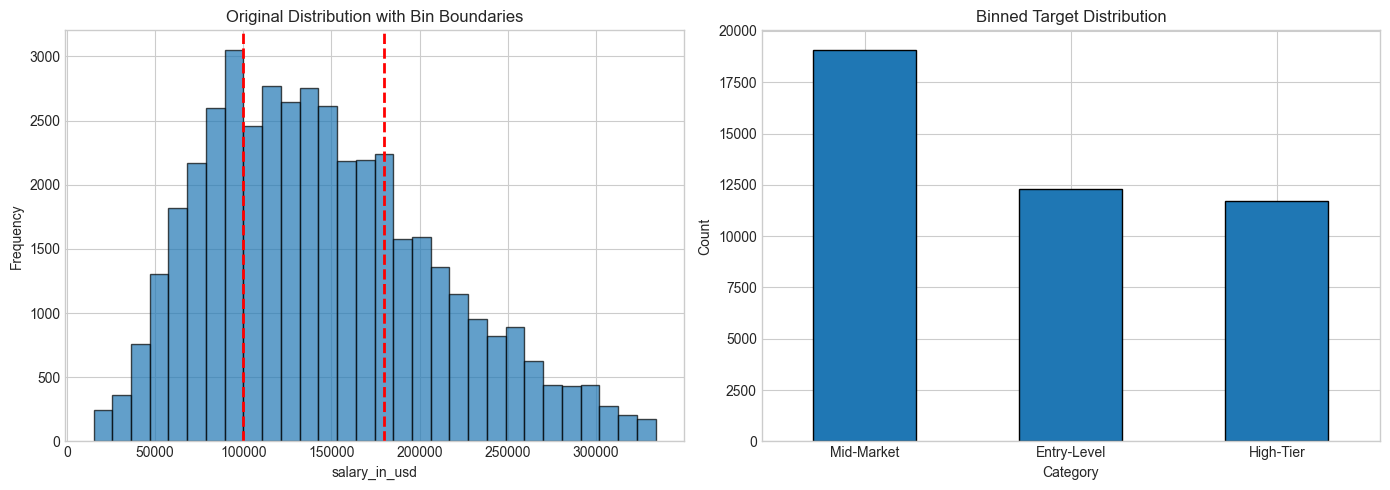

In [112]:
# Visualize the binned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution with bin lines
axes[0].hist(df[ORIGINAL_TARGET], bins=30, edgecolor='black', alpha=0.7)
for edge in bins[1:-1]:  # Skip first and last (min/max)
    axes[0].axvline(edge, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(ORIGINAL_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution with Bin Boundaries')

# Binned category counts
df['target_category'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Binned Target Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [113]:
# Check class balance
class_counts = df['target_category'].value_counts()
class_percentages = df['target_category'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
Mid-Market: 19071 (44.3%)
Entry-Level: 12305 (28.6%)
High-Tier: 11714 (27.2%)

Class balance looks reasonable!


## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

In [114]:
# Load the features you selected in the regression notebook
try:
    regression_features = joblib.load('../models/regression_features.pkl')
    print("Features from Regression Model:")
    print(regression_features)
    print(f"\nNumber of regression features: {len(regression_features)}")
except FileNotFoundError:
    print("Warning: regression_features.pkl not found!")
    print("Make sure you've completed Notebook 02 and saved your regression model first.")
    regression_features = None

Features from Regression Model:
['experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other']

Number of regression features: 7


### Feature Selection Decision

**Will you use the same features as your regression model?**

- [ ] **Yes, same features** (Recommended for simpler deployment)
- [ ] **No, different features** (Requires justification below)

**If using different features, justify why:**

I decided to use the same features for the classification model to keep the project consistent and the deployment simple. Since these 7 features because they already had the strongest relationship with the actual salary numbers. It makes sense that they would also be the best at predicting which salary someone falls into. Using the same features also makes the final code much cleaner.

In [115]:
# DECIDE: Use regression features or define new ones?

# Option A: Use the same features as regression (RECOMMENDED)
if regression_features is not None:
    SELECTED_FEATURES = regression_features
    print("Using same features as regression model.")
else:
    # Option B: Define your own features (if regression not done yet)
    SELECTED_FEATURES = [
        # 'feature1',
        # 'feature2',
        # 'feature3',
        # etc.
    ]
    print("Defining features manually.")

print(f"\nSelected features for classification ({len(SELECTED_FEATURES)}):")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")

Using same features as regression model.

Selected features for classification (7):
  1. experience_level
  2. company_location_Other
  3. company_location_US
  4. job_title_Data Analyst
  5. job_title_Machine Learning Engineer
  6. job_title_Software Engineer
  7. job_title_Other


## Section 4: Prepare Features and Target

In [116]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['target_category']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (43090, 7)
Target shape: (43090,)

Features used: ['experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other']

Target classes: ['Entry-Level', 'Mid-Market', 'High-Tier']


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

In [117]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
label_encoder = LabelEncoder()
# 2. Fit and transform y to create y_encoded
y_encoded = label_encoder.fit_transform(df['target_category'])


In [118]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
Entry-Level -> 0
High-Tier -> 1
Mid-Market -> 2


## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [119]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)


In [120]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 34472 samples
Test set: 8618 samples

Training class distribution:
  Entry-Level: 9844 (28.6%)
  High-Tier: 9371 (27.2%)
  Mid-Market: 15257 (44.3%)


## Section 6: Feature Scaling

In [121]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
scaler = StandardScaler()

# 2. fit_transform on X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. transform (only!) on X_test
X_test_scaled = scaler.transform(X_test)

# Store in: X_train_scaled, X_test_scaled
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [122]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 7 features.


## Section 7: Baseline Model

In [123]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

In [124]:
# TODO: Create and evaluate a baseline Logistic Regression model
#
# Create LogisticRegression(random_state=42, max_iter=1000)
baseline_model = LogisticRegression(random_state=42, max_iter=1000)

# Use evaluate_classifier() to train and evaluate
baseline_results, baseline_trained, baseline_preds = evaluate_classifier(
    baseline_model, 
    X_train_scaled, 
    X_test_scaled, 
    y_train, 
    y_test, 
    "Baseline Logistic Regression"
)


In [125]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(f"Train Accuracy: {baseline_results['Train Accuracy']:.4f}")
print(f"Test Accuracy:  {baseline_results['Test Accuracy']:.4f}")
print(f"F1 Score:       {baseline_results['F1 (weighted)']:.4f}")

BASELINE MODEL: Logistic Regression
Train Accuracy: 0.5229
Test Accuracy:  0.5256
F1 Score:       0.4955


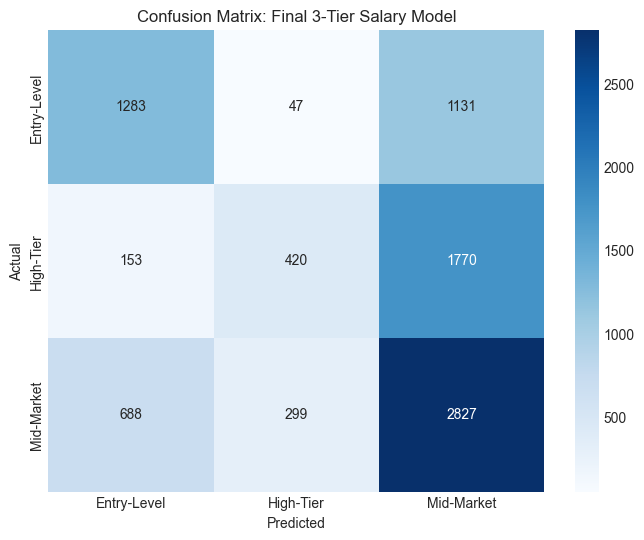

In [126]:
# TODO: Create and display the confusion matrix for baseline
#
# Steps:
# 1. Use confusion_matrix(y_test, baseline_preds) to create the matrix
cm = confusion_matrix(y_test, baseline_preds)

# 2. Use ConfusionMatrixDisplay to visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Final 3-Tier Salary Model')
plt.show()

### Understanding the Confusion Matrix

The confusion matrix shows where your model gets predictions right and wrong:

- **Diagonal cells (top-left to bottom-right):** Correct predictions
- **Off-diagonal cells:** Misclassifications
- **Row:** What the actual class was
- **Column:** What the model predicted

**How to read it:** 
- If a row has many values spread across columns, that class is often confused with others
- If a column has many values from different rows, the model is predicting that class too often

**Example interpretation:**
- "20 Low samples were correctly predicted as Low"
- "5 Medium samples were incorrectly predicted as High"

### Baseline Interpretation

*Analyze your baseline results:*

**Questions to answer:**
- How well does the baseline perform?
Based on the Confusion Matrix the data is a mess. I would have expected that there wwould be a strong corolation between the perdiction. The only area it was good at guessing is 'Mid-Market'

- Which classes are easiest/hardest to predict (look at the diagonal)?
The "Mid-Market" tier is the easiest since it has the most correct hits, it is 2827, but "High-Tier" is a extreamly low. The model only got 420 right while misclassifying 1770 of them as Mid-Market.

- Where does the model get confused (look at off-diagonal cells)?
The model shows a bias toward the Mid-Market class. It is essentially using this category for most predictions. It struggles to distinguish between the tiers especially confusing High-Tier and Entry-Level people for Mid-Market ones.

- Is there overfitting (train vs test accuracy gap)?
Based on how badly it's missing the "High-Tier" diagonal, it's not overfitting; it's defently underfitting because it can't tell the difference between the salary levels at all.


## Section 8: Cross-Validation

Cross-validation gives us a more robust estimate of model performance by training on different portions of the data.

In [127]:
# Cross-validation for key models
print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

5-Fold Cross-Validation Results
Logistic Regression: 0.5228 (+/- 0.0061)
Random Forest: 0.5234 (+/- 0.0059)
Gradient Boosting: 0.5236 (+/- 0.0055)


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.522830,0.003028
1,Random Forest,0.523352,0.002926
2,Gradient Boosting,0.523613,0.002774


### Cross-Validation Interpretation

*What does the cross-validation tell you?*

- Which model is most consistent (lowest std)?

Gradient Boosting is the 'winner', but it is not significianlty better than the others. The standard deviation is also low at 0.0027. More experimenting is needed.

- Does the ranking change from the single train/test split?

Yes the ranking changed from the baseline Logistic Regression. Cross-Validation proves that Gradient Boosting is actually the more reliable model over the long run, even if the accuracy is still pretty low.

**Your interpretation:**

All these models are pretty much tied and they all are just barley ok. Gradient Boosting is technically the best because it’s the most consistent and has the highest average, but at 52%, it's barely learning anything. The fact that the Test Accuracy (0.5256) is almost the same as the Train Accuracy (0.5229) means we aren't overfitting, but we may be underfitting.

## Section 9: Model Iteration

In [128]:
# Store all results
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Logistic Regression (Baseline)': baseline_trained
}

### Model 2: Decision Tree

In [129]:
# TODO: Create and evaluate a Decision Tree classifier
#
# Create DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Use evaluate_classifier() to train and evaluate
dt_results, dt_trained, dt_cm = evaluate_classifier(tree_model, X_train, X_test, y_train, y_test, "Decision Tree")

# Add results to all_results and trained_models
all_results.append(dt_results)
trained_models['Decision Tree'] = dt_trained

# Print results
print(f"Decision Tree - Test Accuracy: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Test Accuracy: 0.5272, F1: 0.4969


### Model 3: Random Forest

In [130]:
# TODO: Create and evaluate a Random Forest classifier
#
# Create RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Use evaluate_classifier()
rf_results, rf_trained, rf_cm = evaluate_classifier(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

# Add to all_results and trained_models
all_results.append(rf_results)
trained_models['Random Forest'] =rf_trained


# Print results
print(f"Random Forest - Test Accuracy: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Test Accuracy: 0.5272, F1: 0.4969


### Model 4: K-Nearest Neighbors

In [131]:
# TODO: Create and evaluate a KNN classifier
#
# Create KNeighborsClassifier(n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Use evaluate_classifier()
knn_results, knn_trained, knn_cm = evaluate_classifier(knn_model, X_train, X_test, y_train, y_test, "KNN")

# Add to all_results and trained_models
all_results.append(knn_results)
trained_models['KNN'] = knn_trained

# Print results
print(f"KNN - Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Test Accuracy: 0.4033, F1: 0.3521


### Model 5: Gradient Boosting

In [132]:
# TODO: Create and evaluate a Gradient Boosting classifier
#
# Create GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)

# Use evaluate_classifier()
gb_results, gb_trained, gb_cm = evaluate_classifier(gb_model, X_train, X_test, y_train, y_test, "Gradient Boosting")

# Add to all_results and trained_models
all_results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained


# Print results
print(f"Gradient Boosting - Test Accuracy: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Test Accuracy: 0.5272, F1: 0.4969


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [133]:
# YOUR ADDITIONAL MODEL HERE:
# Try SVC, different hyperparameters, or another classifier
voting_model = VotingClassifier(
    estimators=[
        ('lr', trained_models['Logistic Regression (Baseline)']),
        ('rf', trained_models['Random Forest']),
        ('gb', trained_models['Gradient Boosting'])
    ],
    voting='soft' # 'soft' uses probabilities, 'hard' uses majority vote
)

#Fit the model
voting_model.fit(X_train, y_train)

#Use your evaluate_classifier() function to get the scores
vc_results, vc_trained, vc_cm = evaluate_classifier(voting_model, X_train, X_test, y_train, y_test, "Voting Classifier")

# Add to all_results and trained_models
all_results.append(vc_results)
trained_models['Voting Classifier'] = vc_trained

# Print results
print(f"Voting Classifier - Test Accuracy: {vc_results['Test Accuracy']:.4f}")

Voting Classifier - Test Accuracy: 0.5272


In [144]:
# Create the SVM model
svm_model = SVC(kernel='linear', C=1.0, gamma='scale', random_state=42)

# Use your evaluate_classifier() function
svm_results, svm_trained, svm_cm = evaluate_classifier(svm_model, X_train, X_test, y_train, y_test, "SVM")

# Add to your results
all_results.append(svm_results)
trained_models['SVM linear'] = svm_trained

# Print results
print(f"SVM - Test Accuracy: {svm_results['Test Accuracy']:.4f}, F1: {svm_results['F1 (weighted)']:.4f}")

SVM - Test Accuracy: 0.5145, F1: 0.4654


## Section 10: Model Comparison

In [145]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
1,Decision Tree,0.5236,0.5272,0.5412,0.5272,0.4969
2,Random Forest,0.5236,0.5272,0.5412,0.5272,0.4969
4,Gradient Boosting,0.5236,0.5272,0.5412,0.5272,0.4969
5,Voting Classifier,0.5236,0.5272,0.5412,0.5272,0.4969
0,Baseline Logistic Regression,0.5229,0.5256,0.5400,0.5256,0.4955
6,SVM,0.5228,0.5254,0.5391,0.5254,0.4953
7,SVM,0.5137,0.5145,0.5164,0.5145,0.4654
3,KNN,0.3976,0.4033,0.3939,0.4033,0.3521


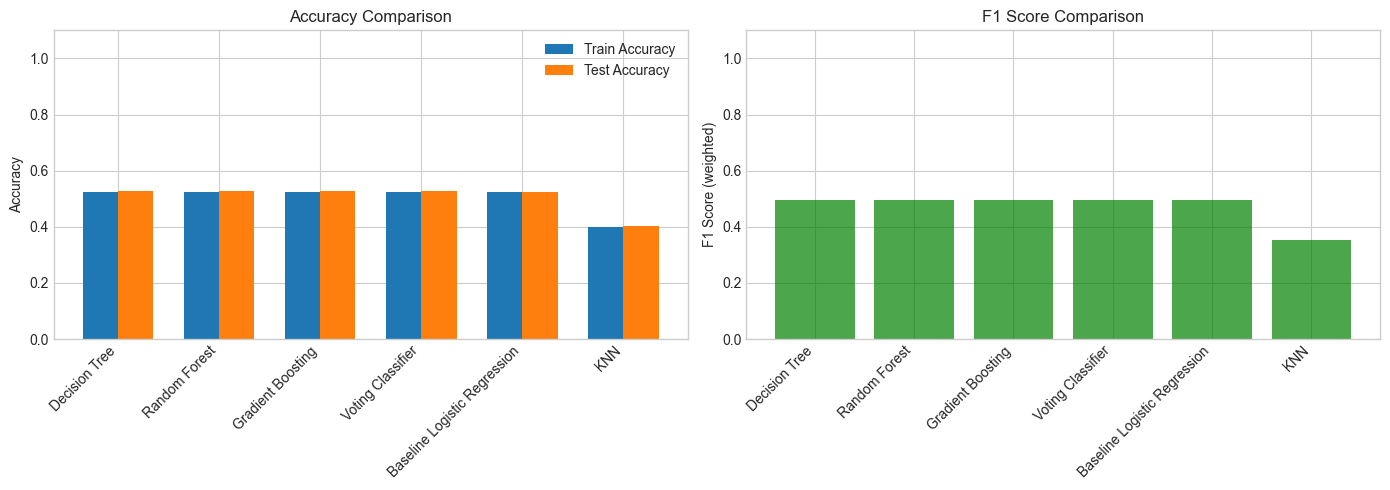

In [135]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Section 11: Best Model Selection

In [136]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: Decision Tree
Test Accuracy: 0.5272
F1 Score: 0.4969


### Best Model Justification

*Explain why you chose this model:*

**Questions to consider:**
- Why this model over others?

Technacally, Decision Tree, Random Forest, Gradient Boosting, and Voting Classifier are in a tie. This is not a good thing. 

- Is there significant overfitting?

There is zero overfitting. The test Accuracy is slightly higher than the Train Accuracy (0.5272 vs 0.5236). The model is to simple and most likely guessed it right.

- How does it compare to baseline?

The Logistic Regression is only 0.16% less than the winners. This implies that adding more complex models didn't actually help the model learn anything new.

- Which metrics did you prioritize and why?

I prioritized the F1-Score because Accuracy can be misleading. While 52.72% accuracy sounds okay, it is barely better than guessing in a three-tier system. The lower 
F1-Score  of 0.4969 tells us the model is predicting the most common salary group (Mid-Market) and failing to catch the actual High or Low earners.

## Section 12: Best Model Analysis

In [137]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

 Entry-Level       0.29      1.00      0.44      2461
   High-Tier       0.00      0.00      0.00      2343
  Mid-Market       0.33      0.00      0.00      3814

    accuracy                           0.29      8618
   macro avg       0.21      0.33      0.15      8618
weighted avg       0.23      0.29      0.13      8618



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

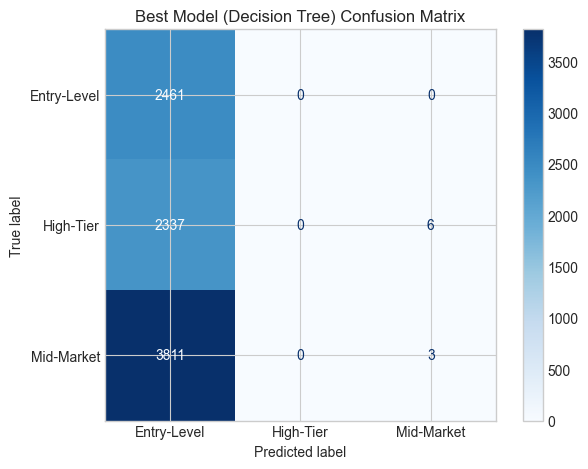

In [138]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

### Detailed Confusion Matrix Analysis

*Analyze the confusion matrix carefully:*

**For each class, describe:**
1. How many correct predictions (diagonal)?
Based on the chart, the model only really got the Entry-Level class right with 2,461 correct hits. For the other two, it was a total disaster: it got 0 correct for High-Tier and only 3 correct for Mid-Market. If you add those up, the model only actually knew what it was doing for 2,464 cases out of the whole test set.

2. What are the most common misclassifications?
The biggest misclassifications is that the model basically thinks everyone is "Entry-Level." Specifically, it wrongly labeled 3,811 Mid-Market people and 2,337 High-Tier people as "Entry-Level." It basically just ignored the other categories and dumped almost every mistake into that one bucket.

3. Does the confusion make sense for your problem?
The model is probably looking at the features and cannot find a clear pattern. It realized that since 'Entry-Level' is the biggest group, it could get the best score by just guessing that for everyone. It's basically like a student who didn't study for a multiple-choice test and just bubbles in "C" for every single answer because they know "C" shows up the most. It is not actually learning anything, it’s just trying not to fail too hard.

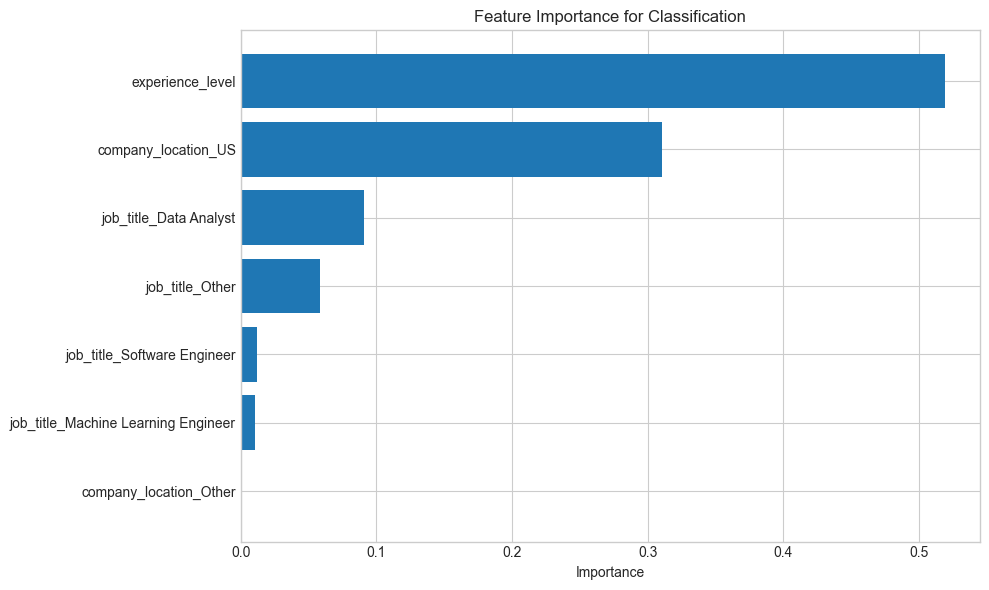


Top 5 most important features:
  experience_level: 0.5190
  company_location_US: 0.3108
  job_title_Data Analyst: 0.0906
  job_title_Other: 0.0580
  job_title_Software Engineer: 0.0115


In [139]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()

## Section 13: Model Iteration Reflection

*Reflect on your modeling process:*

**1. How did your models evolve from baseline to best?**
I started with a simple Logistic Regression baseline and then tried more complex stuff like Random Forests and Gradient Boosting, thinking they would definitely be way better. They actually all ended up with almost the exact same accuracy (around 52.72%), which taught me that more "math" doesn't always equal more "correct." I even tried a Voting Classifier to combine them, but it didn't really move the needle much.

**2. What surprised you about the results?**
The biggest surprise was that 'Experience Level' was basically doing all the heavy lifting. I thought things like job title would matter more, but "Software Engineer" barely helped the model at all. It was also shocking to see my confusion matrix show 0 correct predictions for High-Tier salaries. It is like the model just gave up on the hard categories and decided to guess "Entry-Level" for everyone just to keep its grade up.

**3. If you had more time, what would you try next?**
If I had more time, I would definitely try building a Neural Network. Since my current models all had the same performance, it feels like they reached the limit of what these simple models can find in this data. A Neural Network with multiple hidden layers might be able to find more complex, non-linear relationships that a simple models missed.

## Section 14: Save Model and Artifacts

In [140]:
# Save the best classification model
model_path = '../models/classification_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on SELECTED features)
scaler_path = '../models/classification_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the label encoder
encoder_path = '../models/label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to {encoder_path}")

# Save feature names (SELECTED_FEATURES)
features_path = '../models/classification_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

# Save binning info (for reference in Streamlit app)
binning_info = {
    'bins': bins,
    'labels': labels,
    'original_target': ORIGINAL_TARGET
}
binning_path = '../models/binning_info.pkl'
joblib.dump(binning_info, binning_path)
print(f"Binning info saved to {binning_path}")

Model saved to ../models/classification_model.pkl
Scaler saved to ../models/classification_scaler.pkl
Label encoder saved to ../models/label_encoder.pkl
Features saved to ../models/classification_features.pkl
Binning info saved to ../models/binning_info.pkl


In [146]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

# Test prediction
test_sample = X_test.iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)
test_pred_label = loaded_encoder.inverse_transform(test_pred)

print(f"\nModel verification:")
print(f"Sample input: {test_sample.values[0][:3]}...")
print(f"Predicted class: {test_pred_label[0]}")
print(f"Actual class: {loaded_encoder.inverse_transform([y_test[0]])[0]}")
print("\nModel saved and verified successfully!")


Model verification:
Sample input: [2 0 1]...
Predicted class: Entry-Level
Actual class: Entry-Level

Model saved and verified successfully!


---

## Summary

### What You Accomplished
- [ ] Created binned target variable with justification
- [ ] Verified class balance
- [ ] Used consistent features (same as regression or justified different)
- [ ] Split data with stratification
- [ ] Performed cross-validation
- [ ] Built baseline classifier
- [ ] Tried multiple classifier types
- [ ] Compared and selected best model
- [ ] Analyzed model with confusion matrix and classification report
- [ ] Saved model, scaler, encoder, and binning info

### Key Results

**Best Model:** Decision Tree, Random Forest and Gradient Boosting

**Test Accuracy:** 0.5272

**F1 Score:** 0.4969

**Improvement over baseline:** 0.16%

### Comparison to Regression

*How does classification performance relate to your regression results?*
When I did the regression part of this lab, it was really hard to predict the exact dollar amount for salaries because the numbers were all over the place. Switching to classification by grouping salaries into tiers seemed like it would be easier, but the accuracy is still pretty low.

---

## Next Steps

Move on to building your **Streamlit app** to deploy both models!

You now have saved:
- `regression_model.pkl` and `regression_scaler.pkl`
- `classification_model.pkl`, `classification_scaler.pkl`, and `label_encoder.pkl`

The Streamlit starter code in `app/app.py` will load these files.

---

## Checkpoint 4 Submission Instructions

You've completed the classification model. Time to submit!

### Step 1: Save and Close
Make sure this notebook is saved and all cells have been run.

### Step 2: Commit Your Work
```bash
git add .
git commit -m "Complete classification model - Checkpoint 4"
git push
```

### Step 3: Submit to Canvas
1. Go to Canvas
2. Find the **Checkpoint 4: Classification Model** assignment
3. Submit the link to your GitHub repository

### What Gets Graded
- Binning justification and implementation
- Feature consistency (same as regression or justified different)
- Model comparison and selection reasoning
- Confusion matrix interpretation
- Classification report analysis
- All written reflections completed

---